# Way-point Intercept (Sec 5.1)

Find the uniform reflectance of a 600 kg, 50 m² cube-shaped satellite such that
it reaches a target way-point (defined in height/cross-track/along-track) at a
prescribed time via solar radiation pressure.

In [1]:
import os
import base
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import pandas as pd
from pathlib import Path
from collections import namedtuple

import integrator
import nn
import physics
import utils

jax.config.update('jax_enable_x64', True)
os.makedirs(str(base.PROJECT_ROOT / 'plots' / 'albedo_experiments'), exist_ok=True)

In [2]:
# Spacecraft and propagation parameters
SC_MASS = 600.0       # kg
SC_AREA = 50.0        # m^2
STEP_SIZE = 60.0      # seconds
PROP_HOURS = 96       # total propagation
TARGET_HOURS = 72.0   # time at which way-point is evaluated

# NN proxy trained on albedo-parameterized SRP (GFO geometry, albedo sweep)
NN_WEIGHT_DIR = Path(base.drive_path + 'nn_weights/gfo/grace_grace_albedo_sweep')
nn_params = nn.load_nn_parameters(NN_WEIGHT_DIR / 'parameters.bin')
ray_stats = nn.load_nn_parameters(NN_WEIGHT_DIR / 'ray_stats.bin')
force_stats = nn.load_nn_parameters(NN_WEIGHT_DIR / 'force_stats.bin')

x_min, x_max = jnp.asarray(ray_stats[0], dtype=jnp.float64), jnp.asarray(ray_stats[1], dtype=jnp.float64)
y_min, y_max = jnp.asarray(force_stats[0], dtype=jnp.float64), jnp.asarray(force_stats[1], dtype=jnp.float64)

In [3]:
# Load trajectory and extract a segment starting mid-way through (diverse sun geometry)
df = pd.read_csv(base.drive_path + 'trajectories/gps08.csv')
time_s = 24.0 * 3600.0 * df['MJD'].to_numpy()

start = 1286
end = min(start + PROP_HOURS * 4, len(time_s))

Traj = namedtuple('Traj', 'time position velocity sun')
traj = Traj(
    time=jnp.asarray(time_s[start:end], dtype=jnp.float64),
    position=jnp.asarray(df[['X_m','Y_m','Z_m']].values[start:end], dtype=jnp.float64),
    velocity=jnp.asarray(df[['U_m/s','V_m/s','W_m/s']].values[start:end], dtype=jnp.float64),
    sun=jnp.asarray(df[['x_sun','y_sun','z_sun']].values[start:end], dtype=jnp.float64),
)

t0 = float(traj.time[0])
t1 = float(traj.time[-1])
step_count = int((t1 - t0) / STEP_SIZE)
state0 = (traj.position[0], traj.velocity[0])

print(f'{(t1-t0)/3600:.1f}h propagation, {step_count} steps')

95.8h propagation, 5745 steps


In [4]:
def nadir_pointing(position, velocity):
    z_sc = -position / jnp.linalg.norm(position)
    x_sc = velocity / jnp.linalg.norm(velocity)
    x_sc = x_sc - jnp.dot(x_sc, z_sc) * z_sc
    x_sc = x_sc / jnp.linalg.norm(x_sc)
    y_sc = jnp.cross(z_sc, x_sc)
    return x_sc, y_sc / jnp.linalg.norm(y_sc), z_sc

def sun_direction_body(position, velocity, sun_pos):
    x_sc, y_sc, z_sc = nadir_pointing(position, velocity)
    R = jnp.stack([x_sc, y_sc, z_sc], axis=1)
    sun_vec = (sun_pos - position) / jnp.linalg.norm(sun_pos - position)
    s = R.T @ sun_vec
    lat = jnp.degrees(jnp.arcsin(s[2]))
    lon = jnp.degrees(jnp.arctan2(s[1], s[0]))
    return lat, lon

def eci_to_hcl(pos_ref, vel_ref, pos_target):
    """Convert position difference to Height / Cross-track / Along-track."""
    delta = pos_target - pos_ref
    h_hat = pos_ref / jnp.linalg.norm(pos_ref)
    c_hat = jnp.cross(pos_ref, vel_ref)
    c_hat = c_hat / jnp.linalg.norm(c_hat)
    l_hat = jnp.cross(c_hat, h_hat)
    l_hat = l_hat / jnp.linalg.norm(l_hat)
    return jnp.dot(delta, h_hat), jnp.dot(delta, c_hat), jnp.dot(delta, l_hat)

In [5]:
def param_to_albedo(raw):
    """Map unconstrained parameter to [0, 1] via softsign."""
    return 0.5 * (raw / (1.0 + jnp.abs(raw)) + 1.0)

def build_srp_provider(albedo):
    albedo = jnp.asarray(albedo, dtype=jnp.float64)
    sun_arr, vel_arr, time_arr = traj.sun, traj.velocity, traj.time

    def provider(position, time):
        sun_pos = utils.sample_moonsun_cubic(time, sun_arr, time_arr)
        velocity = utils.sample_moonsun_cubic(time, vel_arr, time_arr)
        lat, lon = sun_direction_body(position, velocity, sun_pos)
        x_sc, y_sc, z_sc = nadir_pointing(position, velocity)

        nn_in = jnp.concatenate((utils.lat_lon_to_cart(lat, lon), albedo[None]))
        whitened = ((nn_in - x_min) / jnp.where(jnp.abs(x_max - x_min) > 1e-12, x_max - x_min, 1.0)).astype(jnp.float32)
        pred = nn.mlp(whitened, nn_params)
        force_sc = jnp.asarray(nn.unwhiten(0.5 * (pred + 1.0), (y_min, y_max)), dtype=jnp.float32)

        R = jnp.stack([x_sc, y_sc, z_sc], axis=1)
        force_eci = R @ force_sc
        shadow = physics.eclipse_model(position, sun_pos)
        force_eci = jnp.where(shadow == 0, jnp.zeros(3, dtype=jnp.float64), force_eci * shadow)
        return (force_eci / SC_MASS) * SC_AREA

    return provider

def force_model(state, time, srp_provider):
    pos, vel = state
    return (vel, physics.compute_gravity(pos) + srp_provider(pos, time))

In [6]:
def propagate(z0, t_start, t_stop, ode, ode_param, n_steps):
    dt = (t_stop - t_start) / n_steps
    def step(carry, t):
        return integrator.integrate_rk4(carry, t, ode, ode_param, dt), carry
    ts = t_start + dt * jnp.arange(n_steps)
    final, history = jax.lax.scan(step, z0, ts)
    history = jax.tree.map(lambda h, f: jnp.concatenate([h, f[None]], axis=0), history, final)
    return jnp.concatenate([ts, jnp.array([t_stop])]), history

def simulate(raw_param):
    provider = build_srp_provider(param_to_albedo(raw_param))
    return propagate(state0, t0, t1, force_model, provider, step_count)

In [7]:
# Compute reference trajectory (high reflectance ~0.955) and target (reflectance 0.6)
ts_ref, states_ref = simulate(jnp.array(10.0))
ts_tgt, states_tgt = simulate(jnp.array(0.25))

time_hours = (np.array(ts_ref) - float(ts_ref[0])) / 3600.0
target_idx = int(np.argmin(np.abs(time_hours - TARGET_HOURS)))

pos_ref_t = states_ref[0][target_idx]
vel_ref_t = states_ref[1][target_idx]
H_tgt, C_tgt, L_tgt = eci_to_hcl(pos_ref_t, vel_ref_t, states_tgt[0][target_idx])

print(f'Target HCL at t+{TARGET_HOURS:.0f}h: H={float(H_tgt):+.2f}m, C={float(C_tgt):+.2f}m, L={float(L_tgt):+.2f}m')
print(f'Total 3D offset: {float(jnp.sqrt(H_tgt**2 + C_tgt**2 + L_tgt**2)):.2f}m')

Target HCL at t+72h: H=-2.53m, C=-0.11m, L=+7.82m
Total 3D offset: 8.22m


In [8]:
def hcl_loss(raw_param):
    _, states = simulate(raw_param)
    H, C, L = eci_to_hcl(pos_ref_t, vel_ref_t, states[0][target_idx])
    return (H - H_tgt)**2 + (C - C_tgt)**2 + (L - L_tgt)**2

loss_and_grad = jax.jit(jax.value_and_grad(hcl_loss))

In [9]:
param = jnp.array(-1.0)  # reflectance = 0.25
optimizer = optax.adam(5e-2)
opt_state = optimizer.init(param)

albedos, losses = [], []

for i in range(200):
    l, g = loss_and_grad(param)
    albedos.append(float(param_to_albedo(param)))
    losses.append(float(l))
    if i % 50 == 0:
        print(f'iter {i:3d}  reflectance={albedos[-1]:.4f}  loss={l:.4f} m\u00b2')
    updates, opt_state = optimizer.update(g, opt_state, param)
    param = optax.apply_updates(param, updates)

print(f'\nFinal reflectance: {float(param_to_albedo(param)):.4f}  loss: {float(loss_and_grad(param)[0]):.6f} m\u00b2')

iter   0  reflectance=0.2500  loss=104.3960 m²


iter  50  reflectance=0.6783  loss=2.1376 m²


iter 100  reflectance=0.5974  loss=0.0057 m²


iter 150  reflectance=0.5992  loss=0.0006 m²



Final reflectance: 0.5999  loss: 0.000002 m²


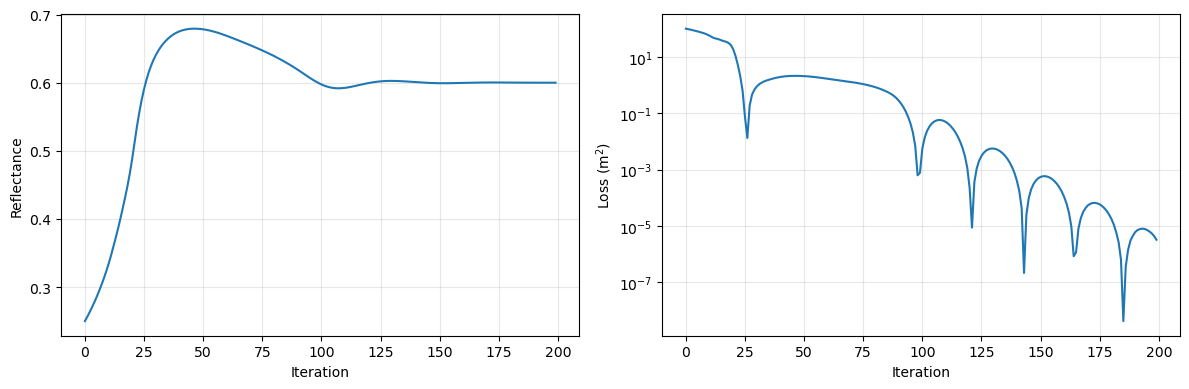

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
iters = np.arange(len(albedos))

ax1.plot(iters, albedos)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Reflectance')
ax1.grid(alpha=0.3)

ax2.semilogy(iters, losses)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss (m$^2$)')
ax2.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(str(base.PROJECT_ROOT / 'plots/albedo_experiments/inverse_point_loss.svg'), dpi=300)
plt.show()

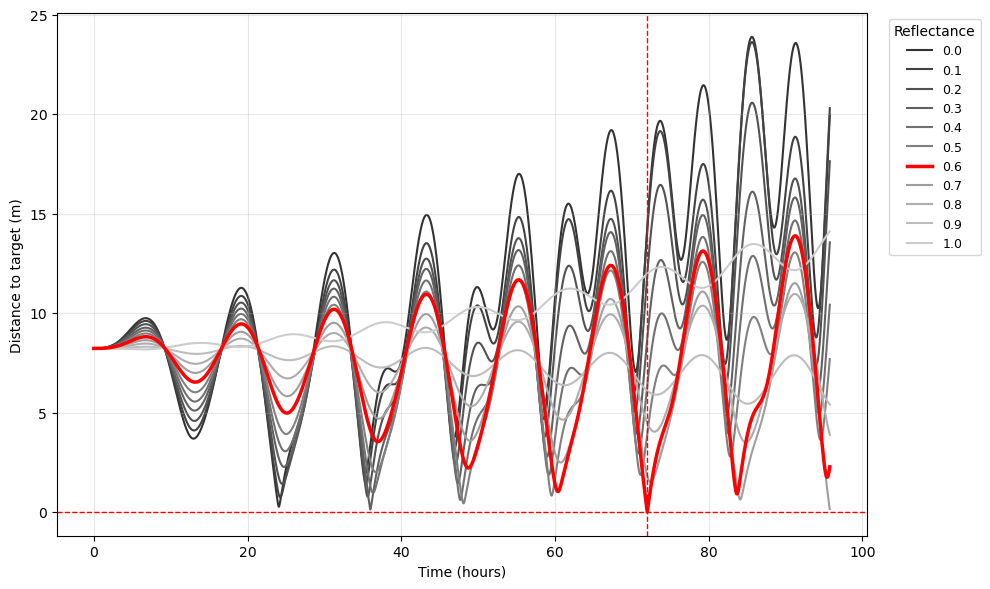

In [11]:
# Fig 8: Distance to target over time for different reflectances
def hcl_timeseries(states_test, states_ref):
    H, C, L = [], [], []
    for i in range(states_test[0].shape[0]):
        h, c, l = eci_to_hcl(states_ref[0][i], states_ref[1][i], states_test[0][i])
        H.append(float(h)); C.append(float(c)); L.append(float(l))
    return np.array(H), np.array(C), np.array(L)

H_tgt_s, C_tgt_s, L_tgt_s = hcl_timeseries(states_tgt, states_ref)
H_tgt_v, C_tgt_v, L_tgt_v = H_tgt_s[target_idx], C_tgt_s[target_idx], L_tgt_s[target_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.axhline(0, color='red', ls='--', lw=1)
ax.axvline(TARGET_HOURS, color='red', ls='--', lw=1)

for refl in np.arange(0.0, 1.01, 0.1):
    s = 2 * refl - 1
    raw = np.clip(s / (1 - abs(s) + 1e-8), -100, 100)
    _, st = simulate(jnp.array(raw))
    H_s, C_s, L_s = hcl_timeseries(st, states_ref)
    dist = np.sqrt((H_s - H_tgt_v)**2 + (C_s - C_tgt_v)**2 + (L_s - L_tgt_v)**2)

    is_target = abs(refl - 0.6) < 0.01
    color = 'red' if is_target else (0.2 + 0.6*refl,)*3
    ax.plot(time_hours, dist, color=color, lw=2.5 if is_target else 1.5,
            zorder=10 if is_target else 1, label=f'{refl:.1f}')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Distance to target (m)')
ax.legend(title='Reflectance', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(base.PROJECT_ROOT / 'plots/albedo_experiments/inverse_point_distance.svg'), dpi=300)
plt.show()